In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

## EDA

In [ ]:
train_transaction = pd.read_csv('train_transaction.csv')
train_identity = pd.read_csv('train_identity.csv')

print(f"train_transaction: {train_transaction.shape}")
print(f"train_identity:    {train_identity.shape}")

train_transaction: (590540, 394)
train_identity:    (144233, 41)


In [ ]:
df = train_transaction.merge(train_identity, on='TransactionID', how='left')
del train_transaction, train_identity

### 1. Class Imbalance — Target Variable (`isFraud`)

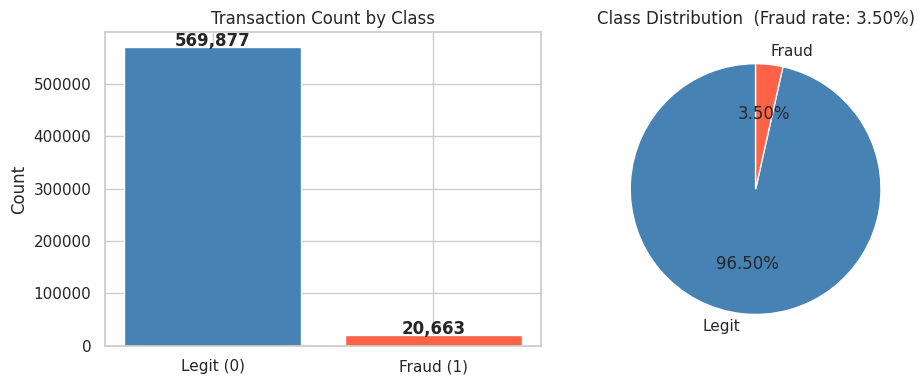

In [ ]:
counts = df['isFraud'].value_counts()
fraud_rate = counts[1] / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Legit (0)', 'Fraud (1)'], counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Transaction Count by Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Legit', 'Fraud'], autopct='%1.2f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title(f'Class Distribution  (Fraud rate: {fraud_rate:.2f}%)')

plt.tight_layout()
plt.show()

### 2. Transaction Amount by Class

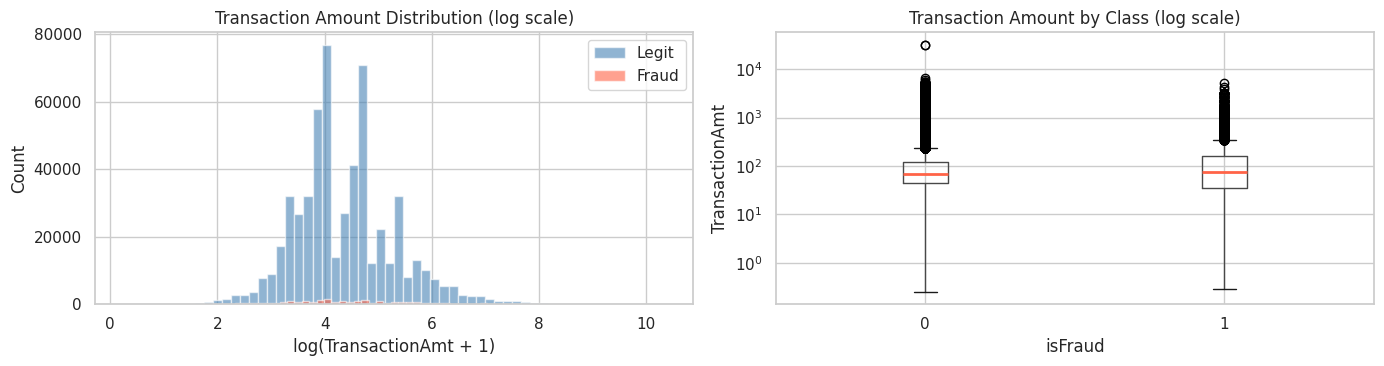

            count    mean     std   min    25%   50%    75%       max
isFraud                                                              
0        569877.0  134.51  239.40  0.25  43.97  68.5  120.0  31937.39
1         20663.0  149.24  232.21  0.29  35.04  75.0  161.0   5191.00


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, color in zip([0, 1], ['steelblue', 'tomato']):
    subset = df[df['isFraud'] == label]['TransactionAmt']
    axes[0].hist(np.log1p(subset), bins=60, alpha=0.6,
                 label=f"{'Fraud' if label else 'Legit'}", color=color)
axes[0].set_title('Transaction Amount Distribution (log scale)')
axes[0].set_xlabel('log(TransactionAmt + 1)')
axes[0].set_ylabel('Count')
axes[0].legend()

df.boxplot(column='TransactionAmt', by='isFraud', ax=axes[1],
           medianprops=dict(color='tomato', linewidth=2))
axes[1].set_yscale('log')
axes[1].set_title('Transaction Amount by Class (log scale)')
axes[1].set_xlabel('isFraud')
axes[1].set_ylabel('TransactionAmt')
plt.suptitle('')
plt.tight_layout()
plt.show()

print(df.groupby('isFraud')['TransactionAmt'].describe().round(2))

### 3. Fraud Rate by Key Categorical Features

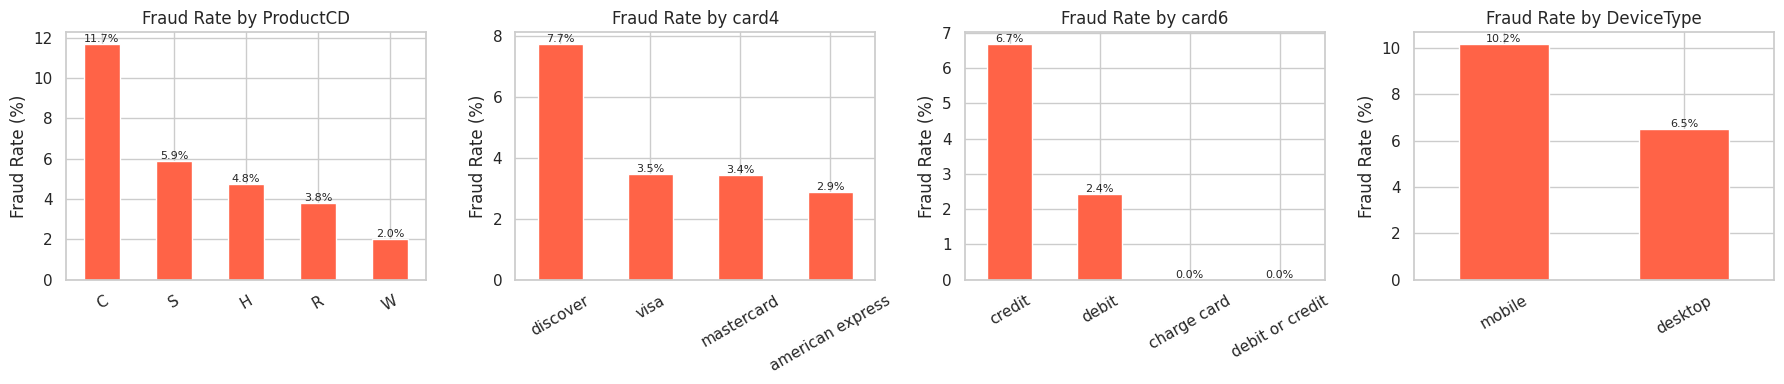

In [ ]:
cat_cols = ['ProductCD', 'card4', 'card6', 'DeviceType']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col in zip(axes, cat_cols):
    fraud_rate_col = df.groupby(col)['isFraud'].mean().sort_values(ascending=False) * 100
    fraud_rate_col.plot(kind='bar', ax=ax, color='tomato', edgecolor='white')
    ax.set_title(f'Fraud Rate by {col}')
    ax.set_ylabel('Fraud Rate (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### 4. Transaction Volume Over Time

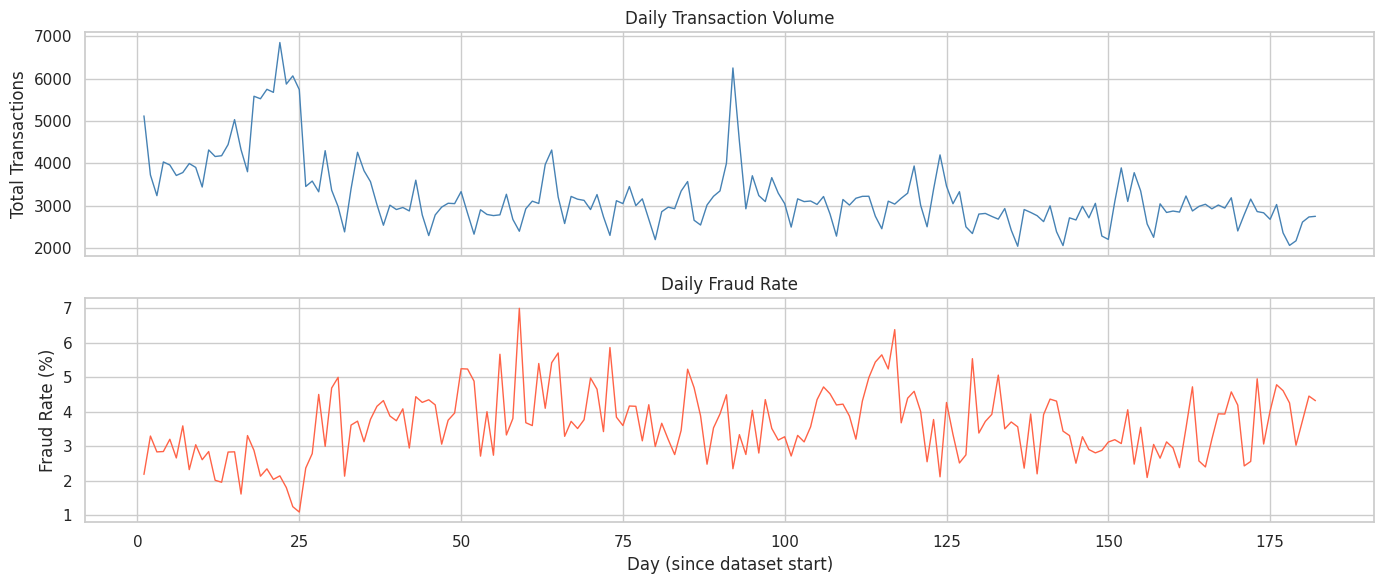

In [ ]:
df['day'] = df['TransactionDT'] // 86400
daily = df.groupby('day')['isFraud'].agg(['count', 'sum'])
daily.columns = ['total', 'fraud']

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(daily.index, daily['total'], color='steelblue', linewidth=1)
axes[0].set_ylabel('Total Transactions')
axes[0].set_title('Daily Transaction Volume')

axes[1].plot(daily.index, daily['fraud'] / daily['total'] * 100, color='tomato', linewidth=1)
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_xlabel('Day (since dataset start)')
axes[1].set_title('Daily Fraud Rate')

plt.tight_layout()
plt.show()

### 5. Missing Values

Columns with missing values: 414 / 435

Missing rate buckets:
(0, 10]       92
(10, 50]     108
(50, 90]     202
(90, 100]     12
Name: count, dtype: int64


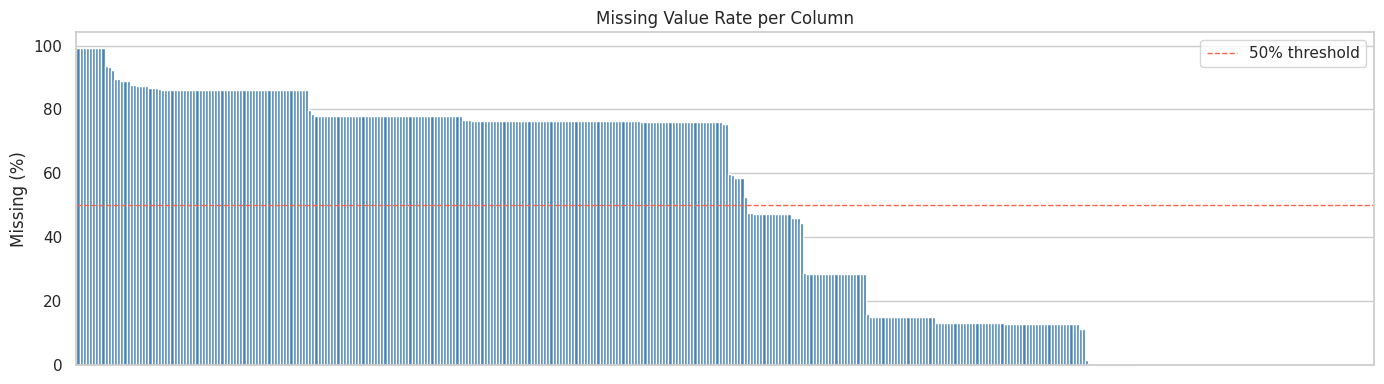

In [ ]:
missing = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_nonzero = missing[missing > 0]

print(f"Columns with missing values: {len(missing_nonzero)} / {df.shape[1]}")
print(f"\nMissing rate buckets:")
print(pd.cut(missing_nonzero, bins=[0, 10, 50, 90, 100]).value_counts().sort_index())

fig, ax = plt.subplots(figsize=(14, 4))
missing_nonzero.plot(kind='bar', ax=ax, color='steelblue', width=1.0)
ax.axhline(50, color='tomato', linestyle='--', linewidth=1, label='50% threshold')
ax.set_title('Missing Value Rate per Column')
ax.set_ylabel('Missing (%)')
ax.set_xticks([])
ax.legend()
plt.tight_layout()
plt.show()

### 6. Top Numeric Features Correlated with Fraud

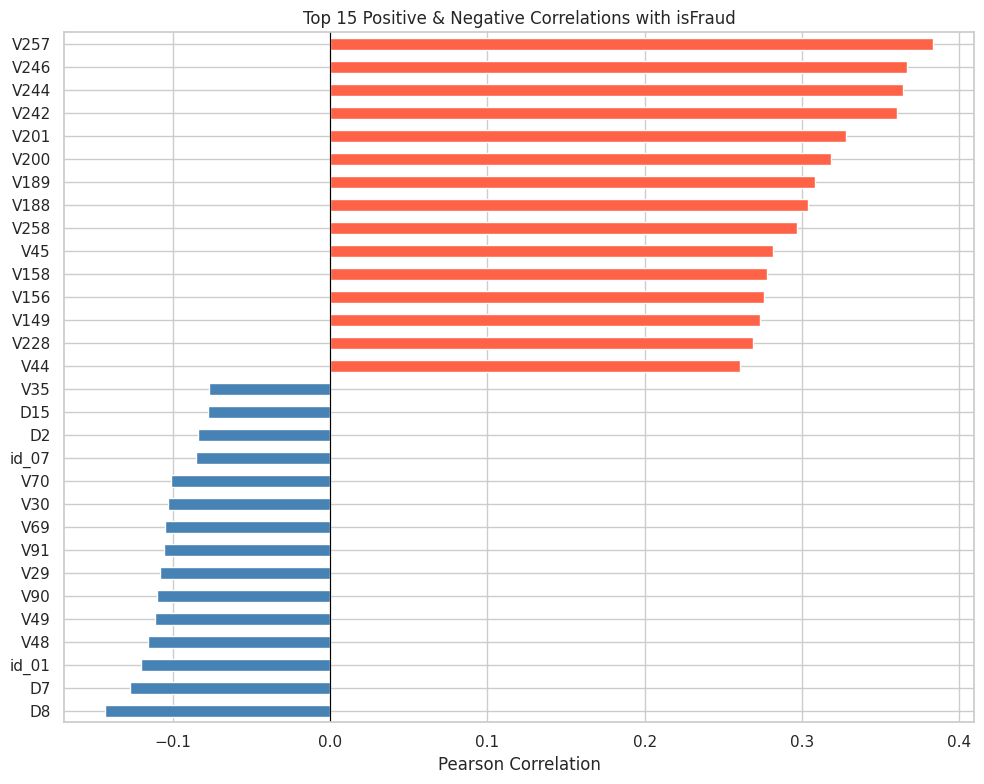

In [ ]:
num_cols = df.select_dtypes(include='number').columns.drop(['TransactionID', 'TransactionDT', 'day', 'isFraud'])
corr = df[num_cols].corrwith(df['isFraud']).dropna()
top = pd.concat([corr.nlargest(15), corr.nsmallest(15)]).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['tomato' if v > 0 else 'steelblue' for v in top.values]
top.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 15 Positive & Negative Correlations with isFraud')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

## Feature Engineering

extreido de: https://www.kaggle.com/code/cdeotte/xgb-fraud-with-magic-0-9600#Feature-Engineering

We will now engineer features. All of these features where chosen because each increases local validation. The procedure for engineering features is as follows. First you think of an idea and create a new feature. Then you add it to your model and evaluate whether local validation AUC increases or decreases. If AUC increases keep the feature, otherwise discard the feature.

In [ ]:
y_train = df['isFraud'].copy()
X_train = df.drop(columns=['isFraud'])

del df
import gc
gc.collect()

63681

In [ ]:
test_transaction = pd.read_csv('test_transaction.csv')
test_identity = pd.read_csv('test_identity.csv')

print(f"test_transaction: {test_transaction.shape}")
print(f"test_identity:    {test_identity.shape}")

test_transaction: (506691, 393)
test_identity:    (141907, 41)


In [ ]:
X_test = test_transaction.merge(test_identity, on='TransactionID', how='left')

del test_transaction, test_identity

In [ ]:
# FREQUENCY ENCODE TOGETHER
def encode_FE(df1, df2, cols):
    for col in cols:
        df = pd.concat([df1[col],df2[col]])
        vc = df.value_counts(dropna=True, normalize=True).to_dict()
        vc[-1] = -1
        nm = col+'_FE'
        df1[nm] = df1[col].map(vc)
        df1[nm] = df1[nm].astype('float32')
        df2[nm] = df2[col].map(vc)
        df2[nm] = df2[nm].astype('float32')
        print(nm,', ',end='')

# LABEL ENCODE
def encode_LE(col,train=X_train,test=X_test,verbose=True):
    df_comb = pd.concat([train[col],test[col]],axis=0)
    df_comb,_ = df_comb.factorize(sort=True)
    nm = col
    if df_comb.max()>32000:
        train[nm] = df_comb[:len(train)].astype('int32')
        test[nm] = df_comb[len(train):].astype('int32')
    else:
        train[nm] = df_comb[:len(train)].astype('int16')
        test[nm] = df_comb[len(train):].astype('int16')
    del df_comb; x=gc.collect()
    if verbose: print(nm,', ',end='')

# GROUP AGGREGATION MEAN AND STD
# https://www.kaggle.com/kyakovlev/ieee-fe-with-some-eda
def encode_AG(main_columns, uids, aggregations=['mean'], train_df=X_train, test_df=X_test,
              fillna=True, usena=False):
    # AGGREGATION OF MAIN WITH UID FOR GIVEN STATISTICS
    for main_column in main_columns:
        for col in uids:
            for agg_type in aggregations:
                new_col_name = main_column+'_'+col+'_'+agg_type
                temp_df = pd.concat([train_df[[col, main_column]], test_df[[col,main_column]]])
                if usena: temp_df.loc[temp_df[main_column]==-1,main_column] = np.nan
                temp_df = temp_df.groupby([col])[main_column].agg([agg_type]).reset_index().rename(
                                                        columns={agg_type: new_col_name})

                temp_df.index = list(temp_df[col])
                temp_df = temp_df[new_col_name].to_dict()

                train_df[new_col_name] = train_df[col].map(temp_df).astype('float32')
                test_df[new_col_name]  = test_df[col].map(temp_df).astype('float32')

                if fillna:
                    train_df[new_col_name] = train_df[new_col_name].fillna(-1)
                    test_df[new_col_name] = test_df[new_col_name].fillna(-1)

                print("'"+new_col_name+"'",', ',end='')

# COMBINE FEATURES
def encode_CB(col1,col2,df1=X_train,df2=X_test):
    nm = col1+'_'+col2
    df1[nm] = df1[col1].astype(str)+'_'+df1[col2].astype(str)
    df2[nm] = df2[col1].astype(str)+'_'+df2[col2].astype(str)
    encode_LE(nm,verbose=False)
    print(nm,', ',end='')

# GROUP AGGREGATION NUNIQUE
def encode_AG2(main_columns, uids, train_df=X_train, test_df=X_test):
    for main_column in main_columns:
        for col in uids:
            comb = pd.concat([train_df[[col]+[main_column]],test_df[[col]+[main_column]]],axis=0)
            mp = comb.groupby(col)[main_column].agg(['nunique'])['nunique'].to_dict()
            train_df[col+'_'+main_column+'_ct'] = train_df[col].map(mp).astype('float32')
            test_df[col+'_'+main_column+'_ct'] = test_df[col].map(mp).astype('float32')
            print(col+'_'+main_column+'_ct, ',end='')

In [ ]:
%%time
# TRANSACTION AMT CENTS
X_train['cents'] = (X_train['TransactionAmt'] - np.floor(X_train['TransactionAmt'])).astype('float32')
X_test['cents'] = (X_test['TransactionAmt'] - np.floor(X_test['TransactionAmt'])).astype('float32')
print('cents, ', end='')
# FREQUENCY ENCODE: ADDR1, CARD1, CARD2, CARD3, P_EMAILDOMAIN
encode_FE(X_train,X_test,['addr1','card1','card2','card3','P_emaildomain'])
# COMBINE COLUMNS CARD1+ADDR1, CARD1+ADDR1+P_EMAILDOMAIN
encode_CB('card1','addr1')
encode_CB('card1_addr1','P_emaildomain')
# FREQUENCY ENOCDE
encode_FE(X_train,X_test,['card1_addr1','card1_addr1_P_emaildomain'])
# GROUP AGGREGATE
encode_AG(['TransactionAmt','D9','D11'],['card1','card1_addr1','card1_addr1_P_emaildomain'],['mean','std'],usena=True)

cents, addr1_FE , card1_FE , card2_FE , card3_FE , P_emaildomain_FE , card1_addr1 , card1_addr1_P_emaildomain , card1_addr1_FE , card1_addr1_P_emaildomain_FE , 'TransactionAmt_card1_mean' , 'TransactionAmt_card1_std' , 'TransactionAmt_card1_addr1_mean' , 'TransactionAmt_card1_addr1_std' , 'TransactionAmt_card1_addr1_P_emaildomain_mean' , 'TransactionAmt_card1_addr1_P_emaildomain_std' , 'D9_card1_mean' , 'D9_card1_std' , 'D9_card1_addr1_mean' , 'D9_card1_addr1_std' , 'D9_card1_addr1_P_emaildomain_mean' , 'D9_card1_addr1_P_emaildomain_std' , 'D11_card1_mean' , 'D11_card1_std' , 'D11_card1_addr1_mean' , 'D11_card1_addr1_std' , 'D11_card1_addr1_P_emaildomain_mean' , 'D11_card1_addr1_P_emaildomain_std' , CPU times: user 8.71 s, sys: 317 ms, total: 9.03 s
Wall time: 9.66 s


### Feature Selection - Time Consistency

In [ ]:
cols = list( X_train.columns )
cols.remove('TransactionDT')
for c in ['D6','D7','D8','D9','D12','D13','D14']:
    cols.remove(c)

# FAILED TIME CONSISTENCY TEST
for c in ['C3','M5','id_08','id_33']:
    cols.remove(c)
for c in ['card4','id_07','id_14','id_21','id_30','id_32','id_34']:
    cols.remove(c)
for c in ['id_'+str(x) for x in range(22,28)]:
    cols.remove(c)

In [ ]:
print('NOW USING THE FOLLOWING',len(cols),'FEATURES.')
np.array(cols)

NOW USING THE FOLLOWING 437 FEATURES.


array(['TransactionID', 'TransactionAmt', 'ProductCD', 'card1', 'card2',
       'card3', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2',
       'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C4', 'C5', 'C6',
       'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2',
       'D3', 'D4', 'D5', 'D10', 'D11', 'D15', 'M1', 'M2', 'M3', 'M4',
       'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7',
       'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17',
       'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26',
       'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35',
       'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44',
       'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53',
       'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62',
       'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71',
       'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80',
      